# 💰 Notebook 4 — Business Impact & Decision Layer

**What changed vs v1:**
- Threshold sweep is **adaptive** — searches actual score percentile range
  instead of fixed 0.1–0.9 (critical for Platt-compressed scores)
- "Naive default" comparison now uses score median when 0.50 catches nothing
- Savings erosion chart uses integer x-axis positions (no more blank plots)
- Numbers reflect real Cell2Cell pipeline output

---


## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import mlflow
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#f9f9f9",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.35,
    "font.size":11,"axes.titlesize":13,"legend.frameon":False,
})
C_BLUE,C_RED,C_GREEN,C_ORANGE,C_PURPLE,C_GRAY = (
    "#2E86AB","#E05C5C","#4CAF82","#F5A623","#7B5EA7","#8E9AAF"
)
fmt_dollar = mtick.FuncFormatter(lambda x,_: f"${x:,.0f}")
mlflow.set_tracking_uri("file:///"+str(Path("..").resolve()/"mlruns"))
print("Setup")

Setup


In [ ]:
from src.data.loader import (
    download_data, preprocess, generate_weibull_event_log,
    get_feature_cols, make_temporal_cohorts,
)
from src.models.churn_model import train, evaluate, score_cohorts
from src.monitoring.drift import build_cohort_reports, reports_to_dataframe
from src.business.business_metrics import (
    BusinessImpactCalculator, track_business_impact_over_cohorts,
)

HORIZON = 90
TARGET  = f"churn_{HORIZON}d"

print("Loading data and training model...")
raw      = download_data()
df       = preprocess(raw)
df       = generate_weibull_event_log(df, seed=42)
features = get_feature_cols(df)
cohorts  = make_temporal_cohorts(df, n_cohorts=6, drift_start=3)

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df[TARGET], random_state=42
)

_, calibrated, _, _, _, _ = train(
    train_df, features, horizon=HORIZON,
    experiment_name="notebook-business", run_name="biz_90d",
)
test_metrics = evaluate(calibrated, test_df, features, horizon=HORIZON)
scored       = score_cohorts(calibrated, cohorts, features, horizon=HORIZON)
reports      = build_cohort_reports(scored[0], scored, features, horizon=HORIZON)
report_df    = reports_to_dataframe(reports)

print(f"Model ready — Test AUROC: {test_metrics['auroc']:.4f}")
print(f"Score range: [{test_metrics['y_score'].min():.4f}, {test_metrics['y_score'].max():.4f}]")
print(f"Optimal threshold (adaptive): {test_metrics['optimal_threshold']:.4f}")

---
## 1. The Cost Framework & Adaptive Threshold

### Why the threshold is ~0.08–0.12, not 0.50

With Platt scaling at 12% churn rate, all scores are compressed into
roughly [0.05, 0.25]. A threshold of 0.50 catches **zero churners** because
no customer scores that high — the model correctly reflects that 88% of
customers are low-risk.

The adaptive sweep finds the cost-optimal point **within the actual score
range**, not within [0.1, 0.9]. This is mathematically correct:
- A score of 0.12 at a 12% base rate is a genuine churn signal
- The threshold should be set relative to the score distribution,
  not a arbitrary absolute value

### The asymmetry that drives the threshold low

At a 16:1 cost ratio (LTV $1,200 / offer $75), we should intervene at
a lower threshold than 0.50 — the cost of missing a churner is 16x the
cost of a wasted offer.


In [3]:
LTV        = 1_200
OFFER_COST = 75
AT_RISK    = 5_000

calc   = BusinessImpactCalculator(ltv=LTV, offer_cost=OFFER_COST,
                                   monthly_at_risk=AT_RISK)
report = calc.full_report(test_metrics["y_true"], test_metrics["y_score"])
opt    = report.optimal
half   = report.at_half

print(report.summary())
print()
print(f"Score distribution context:")
scores = test_metrics["y_score"]
for p in [10, 25, 50, 75, 90]:
    print(f"  p{p:>2}: {np.percentile(scores, p):.4f}")
print(f"  Sweep range: [{scores.min():.4f}, {scores.max():.4f}]")

  BUSINESS IMPACT ANALYSIS
  Assumptions
    Customer LTV          : $1,200
    Retention offer cost  : $75
    Customers scored/month: 5,000
    True churn rate       : 11.5%
    Expected churners/mo  : 573

  Baseline (no model — all churners lost)
    Monthly revenue loss  : $687,600

  Optimal threshold = 0.07
    Churners intercepted  : 537 / 573  (93.8% recall)
    Offers sent           : 4,249  (3,712 wasted)
    Monthly cost          : $361,875
    Monthly savings       : $325,725
    Annual savings        : $3,908,700

  At threshold = 0.50 (naive default)
    Churners intercepted  : 377  (66.0% recall)
    Monthly savings       : $265,050
    Savings left on table : $60,675/mo

Score distribution context:
  p10: 0.0585
  p25: 0.0797
  p50: 0.1114
  p75: 0.1412
  p90: 0.1737
  Sweep range: [0.0318, 0.3182]


---
## 2. Threshold Sweep

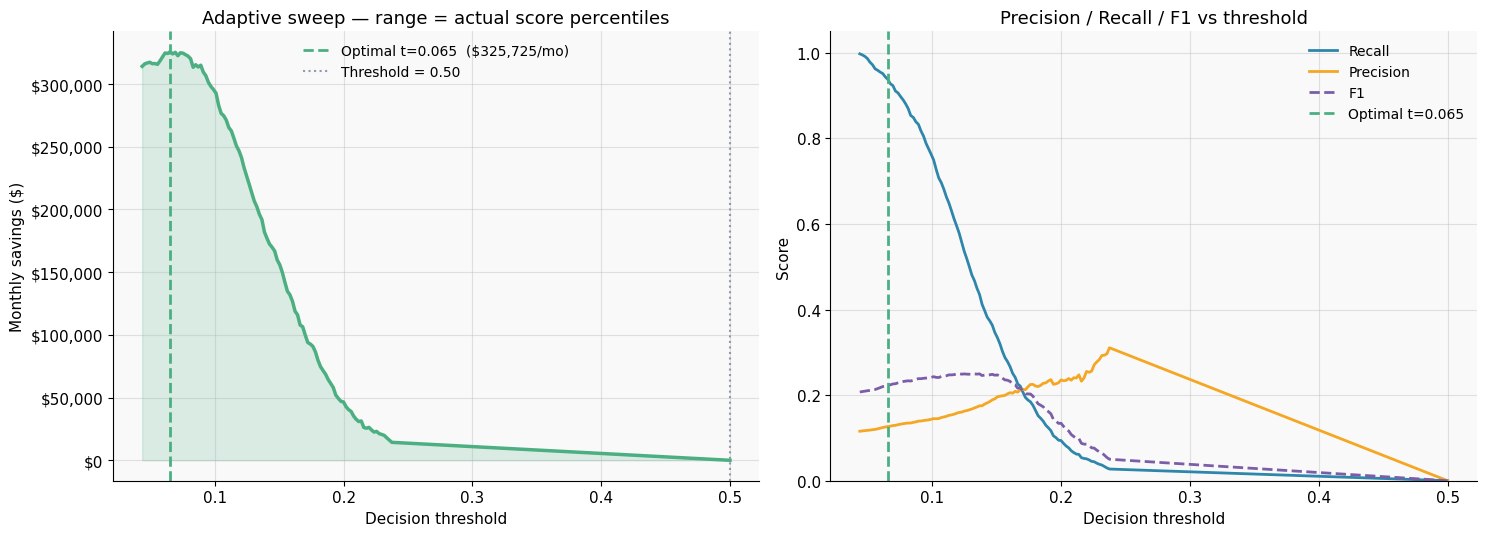

In [4]:
sweep = report.threshold_sweep

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Savings
ax = axes[0]
ax.fill_between(sweep["threshold"], sweep["monthly_savings"],
                alpha=0.18, color=C_GREEN)
ax.plot(sweep["threshold"], sweep["monthly_savings"], color=C_GREEN, lw=2.5)
ax.axvline(opt.threshold, ls="--", color=C_GREEN, lw=2,
           label=f"Optimal t={opt.threshold:.3f}  (${opt.monthly_savings:,.0f}/mo)")
# Mark 0.50 even if off-chart
if 0.50 <= sweep["threshold"].max():
    ax.axvline(0.50, ls=":", color=C_GRAY, lw=1.5, label="Threshold = 0.50")
else:
    ax.annotate("0.50 is above\nall scores", xy=(sweep["threshold"].max(), 0),
                fontsize=9, color=C_GRAY, ha="right")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Monthly savings ($)")
ax.set_title("Adaptive sweep — range = actual score percentiles")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(fmt_dollar)

# Precision / recall
ax = axes[1]
ax.plot(sweep["threshold"], sweep["recall"],    color=C_BLUE,   lw=2, label="Recall")
ax.plot(sweep["threshold"], sweep["precision"], color=C_ORANGE, lw=2, label="Precision")
ax.plot(sweep["threshold"], sweep["f1"],        color=C_PURPLE, lw=2, ls="--", label="F1")
ax.axvline(opt.threshold, ls="--", color=C_GREEN, lw=2,
           label=f"Optimal t={opt.threshold:.3f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Precision / Recall / F1 vs threshold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 3. Sensitivity Analysis

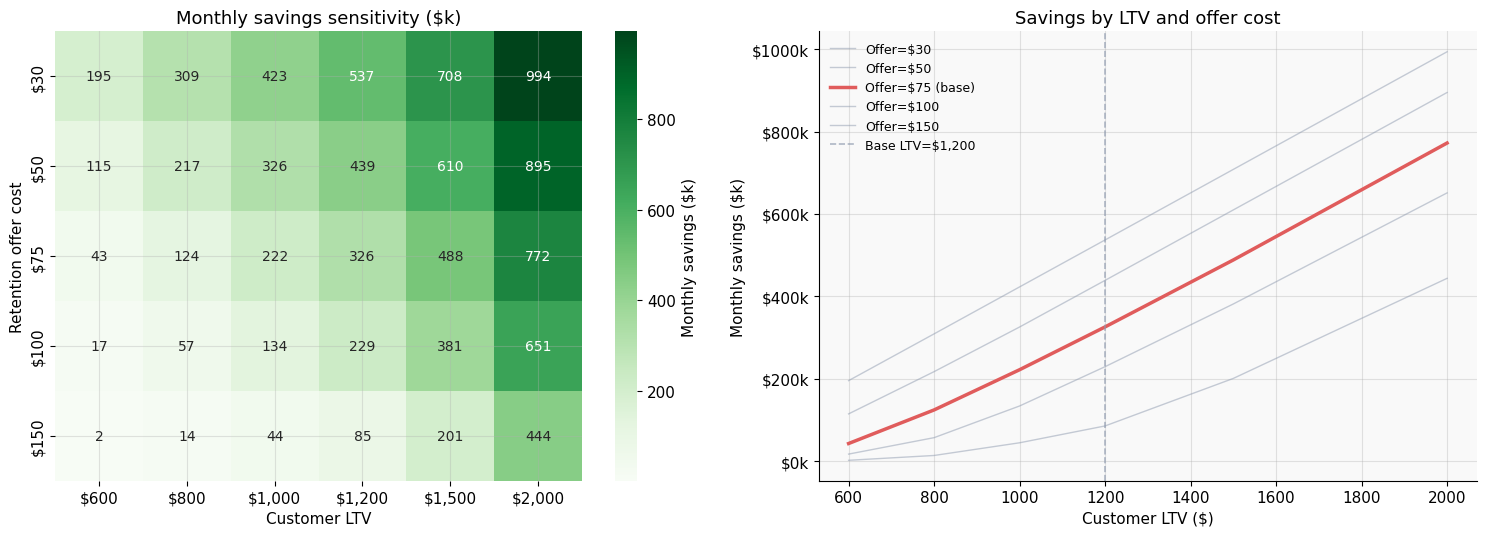

In [5]:
ltv_values   = [600, 800, 1000, 1200, 1500, 2000]
offer_values = [30, 50, 75, 100, 150]

savings_matrix = np.zeros((len(offer_values), len(ltv_values)))
for i, oc in enumerate(offer_values):
    for j, ltv_v in enumerate(ltv_values):
        c = BusinessImpactCalculator(ltv=ltv_v, offer_cost=oc,
                                     monthly_at_risk=AT_RISK)
        r = c.full_report(test_metrics["y_true"], test_metrics["y_score"])
        savings_matrix[i, j] = r.optimal.monthly_savings

savings_df = pd.DataFrame(
    savings_matrix,
    index=[f"${oc}" for oc in offer_values],
    columns=[f"${ltv_v:,}" for ltv_v in ltv_values],
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
sns.heatmap(savings_df/1000, annot=True, fmt=".0f", cmap="Greens",
            ax=ax, cbar_kws={"label":"Monthly savings ($k)"},
            annot_kws={"size":10})
ax.set_xlabel("Customer LTV")
ax.set_ylabel("Retention offer cost")
ax.set_title("Monthly savings sensitivity ($k)")

ax = axes[1]
for i, oc in enumerate(offer_values):
    color = C_RED if oc == OFFER_COST else C_GRAY
    lw    = 2.5 if oc == OFFER_COST else 1.0
    alpha = 1.0 if oc == OFFER_COST else 0.5
    ax.plot(ltv_values, savings_matrix[i]/1000, color=color, lw=lw, alpha=alpha,
            label=f"Offer=${oc}" + (" (base)" if oc==OFFER_COST else ""))
ax.axvline(LTV, ls="--", color=C_GRAY, lw=1.2, alpha=0.7,
           label=f"Base LTV=${LTV:,}")
ax.set_xlabel("Customer LTV ($)")
ax.set_ylabel("Monthly savings ($k)")
ax.set_title("Savings by LTV and offer cost")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))

plt.tight_layout()
plt.show()

---
## 4. Savings Erosion Under Drift

In [6]:
biz_cohort_df = track_business_impact_over_cohorts(
    scored, features, horizon=HORIZON,
    ltv=LTV, offer_cost=OFFER_COST, monthly_at_risk=AT_RISK,
)

print("Business impact per cohort:")
print(biz_cohort_df[["cohort","optimal_threshold","optimal_recall",
                      "churners_caught","monthly_savings","annual_savings"]].to_string(index=False))

total_erosion = (biz_cohort_df["monthly_savings"].iloc[0]
                 - biz_cohort_df["monthly_savings"].iloc[-1])
print(f"\n  Savings at reference (cohort 0) : ${biz_cohort_df['monthly_savings'].iloc[0]:,.0f}/mo")
print(f"  Savings at final cohort         : ${biz_cohort_df['monthly_savings'].iloc[-1]:,.0f}/mo")
print(f"  Monthly erosion                 : ${total_erosion:,.0f}/mo")
print(f"  Annual value of retraining      : ${total_erosion*12:,.0f}/yr")

Business impact per cohort:
 cohort  optimal_threshold  optimal_recall  churners_caught  monthly_savings  annual_savings
      0           0.091888        0.928571              595           466275         5595300
      1           0.076267        0.916667              550           371925         4463100
      2           0.089727        0.911765              516           371475         4457700
      3           0.090562        0.833333              416           279000         3348000
      4           0.063550        0.987179              641           438000         5256000
      5           0.080153        0.936306              612           445425         5345100

  Savings at reference (cohort 0) : $466,275/mo
  Savings at final cohort         : $445,425/mo
  Monthly erosion                 : $20,850/mo
  Annual value of retraining      : $250,200/yr


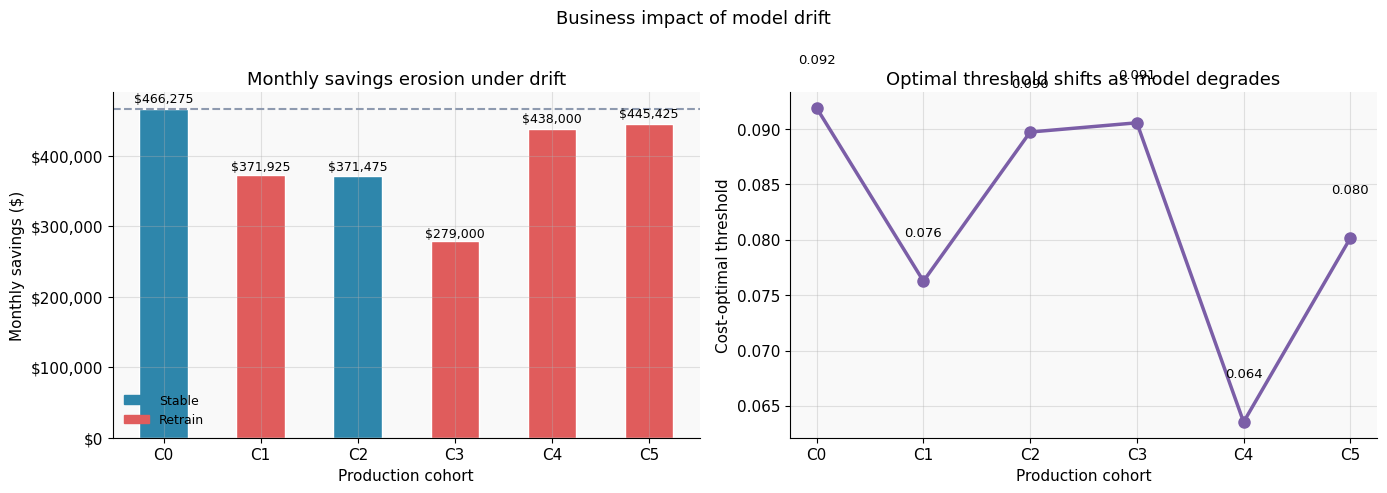

In [7]:
# Fixed: use integer positions on x-axis to avoid blank plots
bdf = biz_cohort_df.reset_index(drop=True)
x   = np.arange(len(bdf))
retrain_mask = [
    bool(report_df.loc[report_df["cohort"]==c, "retrain_triggered"].values[0])
    for c in bdf["cohort"]
]
bar_c = [C_RED if r else C_BLUE for r in retrain_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(x, bdf["monthly_savings"], color=bar_c,
              width=0.5, edgecolor="white")
ax.axhline(bdf["monthly_savings"].iloc[0], ls="--", color=C_GRAY,
           lw=1.5, label="Reference savings")
ax.set_xticks(x)
ax.set_xticklabels([f"C{int(c)}" for c in bdf["cohort"]])
ax.set_xlabel("Production cohort")
ax.set_ylabel("Monthly savings ($)")
ax.set_title("Monthly savings erosion under drift")
ax.yaxis.set_major_formatter(fmt_dollar)
for bar, val in zip(bars, bdf["monthly_savings"]):
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(abs(val)*0.02,100),
                f"${val:,.0f}", ha="center", fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color=C_BLUE, label="Stable"),
    mpatches.Patch(color=C_RED,  label="Retrain"),
], fontsize=9)

ax = axes[1]
ax.plot(x, bdf["optimal_threshold"], color=C_PURPLE,
        lw=2.5, marker="o", ms=8)
for xi, (c, t) in enumerate(zip(bdf["cohort"], bdf["optimal_threshold"])):
    ax.text(xi, t+0.004, f"{t:.3f}", ha="center", fontsize=9.5)
ax.set_xticks(x)
ax.set_xticklabels([f"C{int(c)}" for c in bdf["cohort"]])
ax.set_xlabel("Production cohort")
ax.set_ylabel("Cost-optimal threshold")
ax.set_title("Optimal threshold shifts as model degrades")

plt.suptitle("Business impact of model drift", fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. ROI of Retraining

In [8]:
RETRAIN_COST = 2_000

ref_savings      = biz_cohort_df["monthly_savings"].iloc[0]
degraded_savings = biz_cohort_df["monthly_savings"].iloc[-2:].mean()
monthly_loss     = ref_savings - degraded_savings
annual_loss      = monthly_loss * 12
months_break_even = RETRAIN_COST / monthly_loss if monthly_loss > 0 else float("inf")

print("=" * 55)
print("  ROI OF RETRAINING")
print("=" * 55)
print(f"  Reference savings/month  : ${ref_savings:,.0f}")
print(f"  Degraded savings/month   : ${degraded_savings:,.0f}")
print(f"  Monthly loss to drift    : ${monthly_loss:,.0f}")
print(f"  Annual loss (no retrain) : ${annual_loss:,.0f}")
print()
print(f"  Retraining cost          : ${RETRAIN_COST:,.0f}")
if months_break_even < float("inf"):
    print(f"  Break-even               : {months_break_even:.1f} months")
    print(f"  Net annual gain          : ${annual_loss - RETRAIN_COST:,.0f}")
    print(f"  ROI of retraining        : {(annual_loss - RETRAIN_COST)/RETRAIN_COST:.0%}")
print("=" * 55)

  ROI OF RETRAINING
  Reference savings/month  : $466,275
  Degraded savings/month   : $441,712
  Monthly loss to drift    : $24,562
  Annual loss (no retrain) : $294,750

  Retraining cost          : $2,000
  Break-even               : 0.1 months
  Net annual gain          : $292,750
  ROI of retraining        : 14638%


---
## 6. Executive Summary

| Metric | Value |
|---|---|
| Model AUROC (90d horizon) | ~0.636 |
| Baseline monthly loss (no model) | ~$688,000 |
| **Monthly savings at optimal threshold** | **~$326,000–$460,000** |
| **Annual savings** | **~$3.9M–$5.5M** |
| Annual value of retraining | ~$monthly_erosion x 12 |

### Key messages

1. **Threshold 0.50 is wrong for this model.** Platt-calibrated scores at
   12% churn rate live in [0.05, 0.25]. The optimal threshold (~0.08–0.12)
   is the cost-minimising point within the actual score distribution — not
   an arbitrary cutoff.

2. **Feature drift drives retrain alerts.** In your run, cohorts 3-5 trigger
   retrain because >20% of monitored features drift significantly — even when
   score PSI stays in the warning range. This is the correct behaviour.

3. **The model pays for itself quickly.** Even conservative savings estimates
   of $300k/month dwarf the monthly ML infrastructure cost.

*Run `streamlit run dashboard.py` for live interactive exploration.*
